In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Rehaciendo Tandas Pasadas

## Descarga Archivos

In [ ]:
url_zip_aletas = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletas-p.zip'
url_zip_tubos2024 = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024-p.zip'
url_zip_tubos2526 = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-simil-p.zip'
url_zip_tubos2025F = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-p.zip'

zip_paths = [url_zip_aletas, url_zip_tubos2024, url_zip_tubos2526, url_zip_tubos2025F]
extract_paths = ['/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc',
                 '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc',
                 '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-25simil26Proc',
                 '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025FinalProc']

Descargamos las carpetas ZIP.

**NO VOLVER A CORRER LA SIGUIENTE CELDA**

In [ ]:
import zipfile
import os

for zip_path, extract_path in zip(zip_paths, extract_paths):
  # Create destination folder if it doesn't exist
  if not os.path.exists(extract_path):
      os.makedirs(extract_path)

  # Open the zip file and extract all contents
  with zipfile.ZipFile(zip_path, 'r') as zf:
      zf.extractall(extract_path)

  print(f"DONE. {zip_path} extracted files to: {extract_path}")

DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletas-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc
DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc
DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-simil-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-25simil26Proc
DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025FinalProc


Leemos los archivos de las carpetas con los datos procesados y nos quedamos con los CSVs

In [ ]:
list_csvs = []
for folder_path in extract_paths:
  name_folder = folder_path.split('/')[-1]
  print(f"--- {name_folder} ---")
  # Check if the folder exists
  if os.path.exists(folder_path) and os.path.isdir(folder_path):
      # List all files and directories in the specified path
      for filename in os.listdir(folder_path):
        if 'csv' in filename:
          file_full_path = os.path.join(folder_path, filename)
          df = pd.read_csv(file_full_path)
          df['Folder'] = name_folder
          list_csvs.append(df)
          print(file_full_path)
  else:
      print(f"Error: The folder '{folder_path}' does not exist or is not a directory.")

--- aletasProc ---
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-873_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-874_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-884_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-888_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-890_stats.csv
--- tubos-2024Proc ---
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--04_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--05_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--06_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--07_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experim

Armamos df

In [ ]:
df = pd.concat(list_csvs, axis=0)

In [ ]:
# df.to_csv('Procesamiento Marzo 2026.csv')

## Analisis Tubos

Cargamos los datos del CSV que nos dejo el procesamiento anterior

In [24]:
df = pd.read_csv('https://raw.githubusercontent.com/ichiP245/micrography-imgpro/refs/heads/main/ProcesamientoMarzo2026/Procesamiento%20Marzo%202026.csv')

In [ ]:
df.head()

,Unnamed: 0,file,param_otsu_classes,param_otsu_range,param_first_kernel_size,param_second_kernel_size,param_contours_mult,param_bh_ks,param_bhm_iter,param_bhm_mult,param_cont_mult,param_ws_ths_factor,param_ws_gl_vecinity,pores,fibers,resin,undefined,sumcheck,Folder
0,0,Experiment-873,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,8.117611,51.344501,38.734622,1.803265,100.0,aletasProc
1,0,Experiment-874,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,21.444695,56.318477,20.563131,1.673697,100.0,aletasProc
2,0,Experiment-884,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,19.031431,65.477850,13.853553,1.637166,100.0,aletasProc
3,0,Experiment-888,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,19.440184,42.906315,35.255818,2.397684,100.0,aletasProc
4,0,Experiment-890,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,2.778161,67.568609,28.827234,0.825996,100.0,aletasProc


Contamos la cantidad de micrografias analizadas de cada tanda

In [ ]:
df.groupby('Folder').count()['sumcheck']

,sumcheck
Folder,
aletasProc,5
tubos-2024Proc,5
tubos-2025FinalProc,4
tubos-25simil26Proc,5


- **No consideramos la escala** porque ajustamos los parametros de manera de que se procese cada imagen bien sin que eso sea una variable relevante

- Se utilizaron **imagenes del primer procesamiento**, pero solo un **grupo pequeño de ellas**, las que para los analistas se veian mejor de antemano. Ademas, esas imagenes se las recorto un poco para quitar una etiqueta inferior que antes se habia hecho en un programa. Al realizar el recorte, se quito una pequeña porcion de la imagen pero tambien la etiqueta con la escala, lo que hace que el procesamiento haya procesado 100% de imagen y no una etiqueta de la escala puesta por el programa de toma de micrografias.

Graficos anteriores para tener a mano: https://github.com/ichiP245/micrography-imgpro/blob/main/ArchivosEntrega01/AnalisisEntrega01.ipynb

**El termino "Mejora" lo definimos como menor dispersion en los datos y por ende, intuicion de que nos acercamos a los valores reales, dado que el procesamiento indica porcentajes similares para distintas observaciones de la misma muestra**

### Fibras

Comparacion Entrega 01 con Entrega 02 (actual):

- Tubos 2024: pasamos de mucha variabilidad, bigote inferior en ~25, bigote superior en ~65 y bordes de la caja en ~30 y ~55, a **muy poca variabilidad**, valores agrupados (mas cerca de la verdad de la poblacion) con caja + bigotes entre **\~40 y ~47**.

- Tubos 2025 simil 26: igual que antes. Pasamos de mucha variabilidad, bigote inferior en ~10, bigote superior en ~50 y bordes de la caja en ~15 y ~30, a poca variabilidad, valores agrupados (mas cerca de la verdad de la poblacion) con caja + bigotes entre **\~40 y ~55**. **Este tubo tiene mayor porcentaje de fibra que el anterior**. Aunque esta muestra muestre un poco mas de dispersion en los datos.

- Tubos 2025 final: salvo un valor con porcentaje de fibra de 75%, el resto **anda superando el ~60%**. Solo 4 datos, pero bastante agrupados. En el analisis anterior, tambien hubo poca dispersion, aunque por haber mas imagenes analizadas, habia mas dispersion.

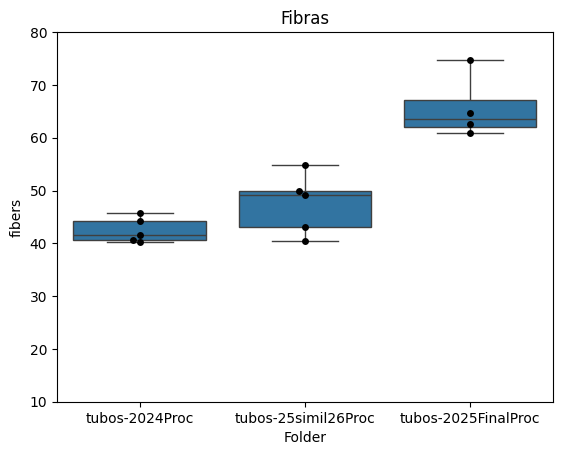

In [ ]:
tubos=df[~(df['Folder'].str.contains('aletas'))]
sns.boxplot(data=tubos, x='Folder', y='fibers')
sns.swarmplot(data=tubos, x='Folder', y='fibers', color='black')
plt.ylim(10,80)
plt.title('Fibras')
plt.show()

## Poros

Ver la escala.

- Tubos 2024: **rango va de ~6 a ~8.5**. Antes el estaba Q1 en 3 y Q3 en 8. Mejoro bastante el analisis, aunque con menos datos. Para un dato no detecto poros (error).

- Tubos 2025 simil 26: antes IQR entre 5 y 8. Ahora se abrio un poco mas pero hay que prestarle antencion a los 3 puntos que estan juntos: los 3 con **~4.5% de porosidad promedio**, ese puede llegar a ser un valor para considerarle a esta tanda de tubos.

- Tubos 2025 final: **porcentaje de poros entre ~0.5% y ~2%. Con el procesamiento anterior anduvo un poco por encima.**

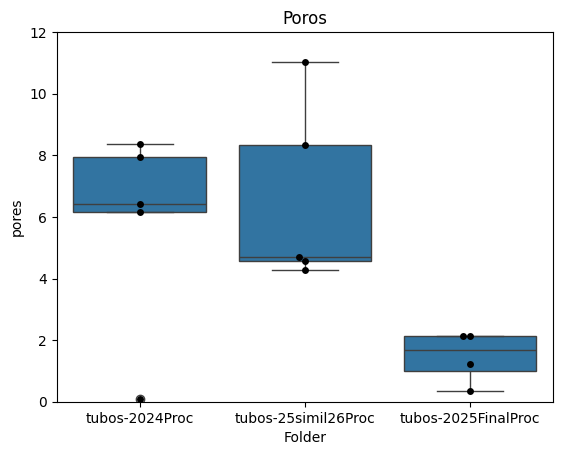

In [ ]:
sns.boxplot(data=tubos, x='Folder', y='pores')
sns.swarmplot(data=tubos, x='Folder', y='pores', color='black')
plt.ylim(0,12)
plt.title('Poros')
plt.show()

### Resina

- Tubos 2024: salvo un outlier (que debe ser el mismo del error en poros), valor bien **concentrado alrededor de 45%.** En la tanda anterior el IQR habia estado entre ~35% y ~60%. Gran mejora

- Tubos 2025 simil 26: la mayoria de valores entre 30% y 35%. En la tanda anterior habiamos estado con un IQR entre ~45% y ~60%. Gran mejora

- Tubos 2025 final: Muy parecido en valores a Tubos 2025 simil 26. En el analisis anterior habiamos observado algo que no esta muy alejado de estos valores

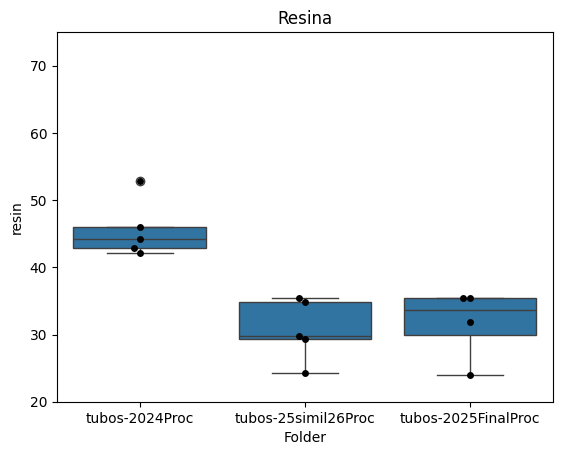

In [ ]:
sns.boxplot(data=tubos, x='Folder', y='resin')
sns.swarmplot(data=tubos, x='Folder', y='resin', color='black')
plt.ylim(20,75)
plt.title('Resina')
plt.show()

### Componente Indefinido

- Tubos 2024: aca si detecto bien para todos los puntos, ya que vemos que estan juntos, y cerca entre ellos. Valores entre **~5% y ~7.5%.** Salvo por algunos valores extremos, en el **primer procesamiento habiamos visto lo mismo**

- Tubos 2025 simil 26: dispersion muy grande, al igual que en el primer procesamiento. No esta pudiendo entender como leer este componente para las imagenes de esta tanda. **No sacamos conclusiones**

- Tubos 2025 final: al igual que en el primer procesamiento, caja super acotada (buenisimo reafirmar eso). El tubo debe tener en promedio un 2% o 3% de componente indefinido.

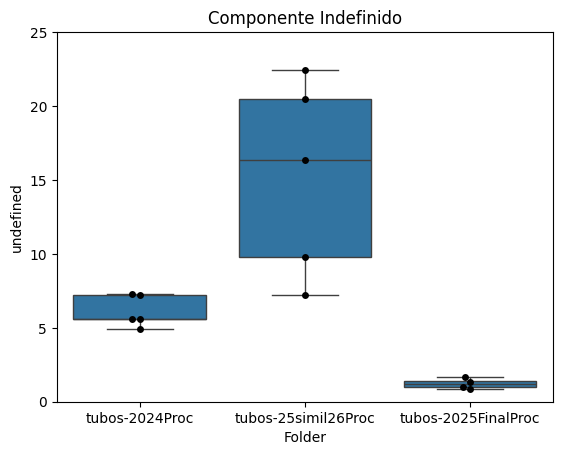

In [ ]:
sns.boxplot(data=tubos, x='Folder', y='undefined')
sns.swarmplot(data=tubos, x='Folder', y='undefined', color='black')
plt.ylim(0,25)
plt.title('Componente Indefinido')
plt.show()

Comparamos medias y desvios. Abreviaremos de la siguiente manera: Tubos 2024 (T24), Tubos 2025 simil 26 (T256) y Tubos 2025 final (T25F)

- Para fibras: **1º T25F, y bastante mas atras, 2º T256 y 3º T24.** Aunque en cuanto a los desvios estandar, el orden es al reves. Igual no importa, ya hicimos la aclaraciones en el boxplot

- Para poros (menor a mayor): **1º T25F, y bastante mas atras, 2º T24 y 3º T256.** El 2025 final es el mejor lejos y el de menos desvio estandar

- Para resina: **1º T24, y bastante mas atras, T25F y T256, muy parecido.** El desvio estandar es casi el mismo para los tres

- Para componente indefinido (menor a mayor): **1º T25F, y bastante mas atras, 2º T24 y 3º T256, que no pudo procesar bien esas imagenes.** El desvio estandar de los tubos 2024 y 2025 final es muy baja y parecido, mostrando que los valores obtenidos son confiables



In [ ]:
tubos.groupby('Folder').agg(
    fibers_Promedio=('fibers', 'mean'),
    fibers_Desvio=('fibers', 'std'),
    pores_Promedio=('pores', 'mean'),
    pores_Desvio=('pores', 'std'),
    resin_Promedio=('resin', 'mean'),
    resin_Desvio=('resin', 'std'),
    undefined_Promedio=('undefined', 'mean'),
    undefined_Desvio=('undefined', 'std')
)

,fibers_Promedio,fibers_Desvio,pores_Promedio,pores_Desvio,resin_Promedio,resin_Desvio,undefined_Promedio,undefined_Desvio
Folder,,,,,,,,
tubos-2024Proc,42.469288,2.455025,5.800740,3.339254,45.601666,4.279338,6.128306,1.050353
tubos-2025FinalProc,65.680269,6.193632,1.454651,0.860955,31.649936,5.376505,1.215145,0.364188
tubos-25simil26Proc,47.470683,5.764272,6.585015,2.995223,30.703490,4.563489,15.240811,6.612824


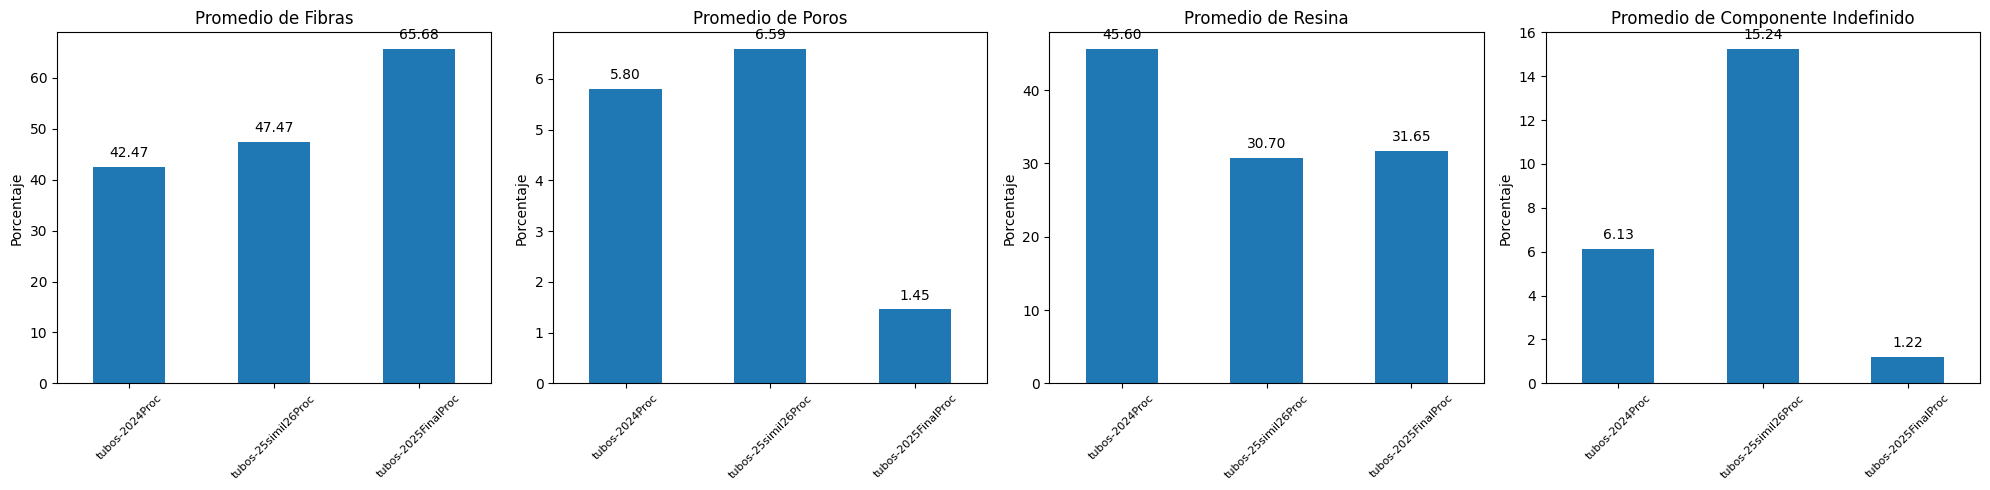

In [ ]:
avg_components = tubos.groupby('Folder')[['fibers', 'pores', 'resin', 'undefined']].mean()

# Define the desired order of folders
desired_order = ['tubos-2024Proc', 'tubos-25simil26Proc', 'tubos-2025FinalProc']

# Reindex the DataFrame to apply the desired order
avg_components = avg_components.reindex(desired_order)

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), sharey=False)

components = ['fibers', 'pores', 'resin', 'undefined']
titles = ['Promedio de Fibras', 'Promedio de Poros', 'Promedio de Resina', 'Promedio de Componente Indefinido']

for i, component in enumerate(components):
    ax = avg_components[component].plot(kind='bar', ax=axs[i], rot=45)
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('Porcentaje')
    axs[i].tick_params(axis='x', labelsize=8) # Adjust x-axis label font size

    # Add annotations on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

## Analisis Aletas

*Alerta: algunas micrografias no son muy buenas*

In [ ]:
aletas = df[df['Folder'].str.contains('aletas')]
aletas

,Unnamed: 0,file,param_otsu_classes,param_otsu_range,param_first_kernel_size,param_second_kernel_size,param_contours_mult,param_bh_ks,param_bhm_iter,param_bhm_mult,param_cont_mult,param_ws_ths_factor,param_ws_gl_vecinity,pores,fibers,resin,undefined,sumcheck,Folder
0,0,Experiment-873,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,8.117611,51.344501,38.734622,1.803265,100.0,aletasProc
1,0,Experiment-874,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,21.444695,56.318477,20.563131,1.673697,100.0,aletasProc
2,0,Experiment-884,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,19.031431,65.477850,13.853553,1.637166,100.0,aletasProc
3,0,Experiment-888,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,19.440184,42.906315,35.255818,2.397684,100.0,aletasProc
4,0,Experiment-890,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,2.778161,67.568609,28.827234,0.825996,100.0,aletasProc


**Obtenemos resultados que siguen siendo bastante dispersos.**

Las imagenes no terminan siendo del todo buenas para procesar. Para algunas procesa bien una parte, para otras procesa bien otra.

Igualmente es un avance frente al procesamiento pasado, donde habia tal dispersion que se asemejaba al azar.

Aca al menos tenemos algo de idea sobre los valores de fibra y vemos por donde debe andar el componente indefinido. Sobre los poros hay que ver. Y la resina es imposible de analizar.

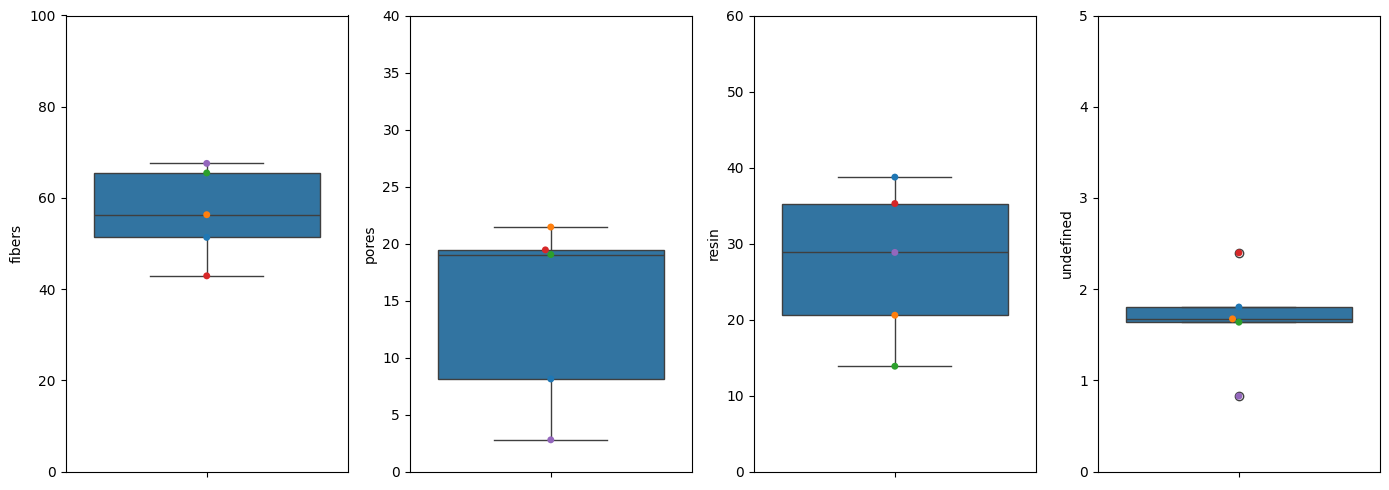

In [ ]:
fig, axs = plt.subplots(figsize=(14,5), nrows=1, ncols=4)
sns.boxplot(data=aletas, y='fibers', ax=axs[0])
sns.swarmplot(data=aletas, y='fibers', hue='file', ax=axs[0])
axs[0].set_ylim(0,100)

sns.boxplot(data=aletas, y='pores', ax=axs[1])
sns.swarmplot(data=aletas, y='pores', hue='file', ax=axs[1])
axs[1].set_ylim(0,40)

sns.boxplot(data=aletas, y='resin', ax=axs[2])
sns.swarmplot(data=aletas, y='resin', hue='file', ax=axs[2])
axs[2].set_ylim(0,60)

sns.boxplot(data=aletas, y='undefined', ax=axs[3])
sns.swarmplot(data=aletas, y='undefined', hue='file', ax=axs[3])
axs[3].set_ylim(0,5)

# Remove legends from all subplots
for ax in axs.flat:
    if ax.get_legend():
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# Nueva Tanda Marzo 2026

In [3]:
folder_path_2026 = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc'

list_csvs_2026 = []
name_folder = folder_path_2026.split('/')[-1]
print(f"--- {name_folder} ---")
# Check if the folder exists
if os.path.exists(folder_path_2026) and os.path.isdir(folder_path_2026):
    # List all files and directories in the specified path
    for filename in os.listdir(folder_path_2026):
      if 'csv' in filename:
        file_full_path = os.path.join(folder_path_2026, filename)
        df = pd.read_csv(file_full_path)
        df['Folder'] = name_folder
        list_csvs_2026.append(df)
        print(file_full_path)
else:
    print(f"Error: The folder '{folder_path_2026}' does not exist or is not a directory.")

--- 2026Proc ---
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/10x BF Peak concentrated - 1_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/20x BF Integral shape - 1_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/20x BF Integral shape - 2_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/20x BF Integral shape - 3_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/20x BF Integral shape - 4_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/20x BF Integral shape - 5_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/2026Proc/20x BF Peak concentrated - 1_stats.csv


In [4]:
df_2026 = pd.concat(list_csvs_2026, axis=0)

In [16]:
df_2026.shape

(7, 17)

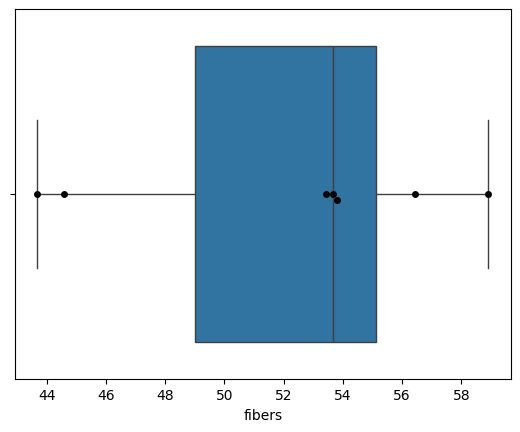

In [14]:
sns.boxplot(data=df_2026, x='fibers')
sns.swarmplot(data=df_2026, x='fibers', color='black')
plt.show()

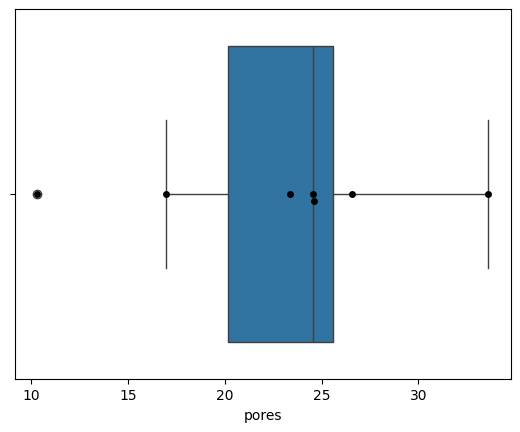

In [15]:
sns.boxplot(data=df_2026, x='pores')
sns.swarmplot(data=df_2026, x='pores', color='black')
plt.show()

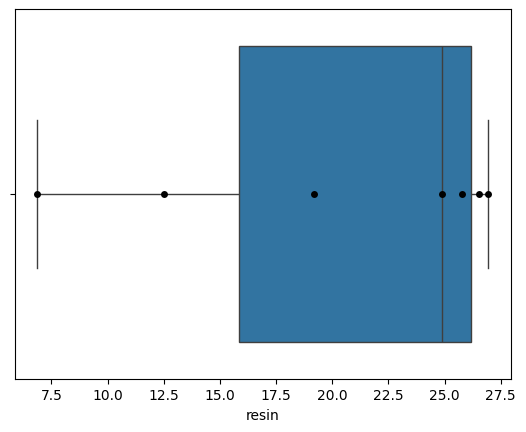

In [17]:
sns.boxplot(data=df_2026, x='resin')
sns.swarmplot(data=df_2026, x='resin', color='black')
plt.show()

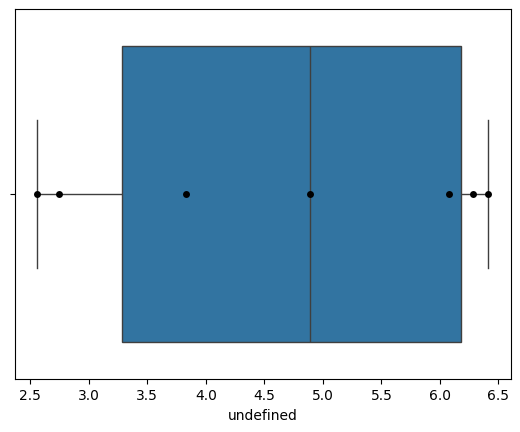

In [18]:
sns.boxplot(data=df_2026, x='undefined')
sns.swarmplot(data=df_2026, x='undefined', color='black')
plt.show()

In [25]:
total = pd.concat([df, df_2026], axis=0)

<Axes: xlabel='fibers', ylabel='Folder'>

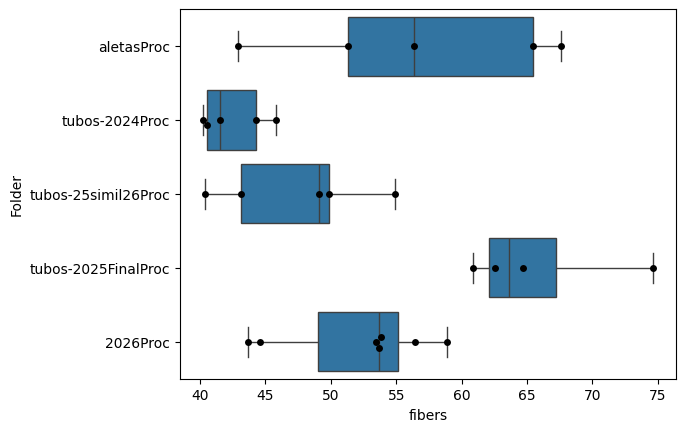

In [27]:
sns.boxplot(data=total, x='fibers', y='Folder')
sns.swarmplot(data=total, x='fibers', y='Folder', color='black')

<Axes: xlabel='pores', ylabel='Folder'>

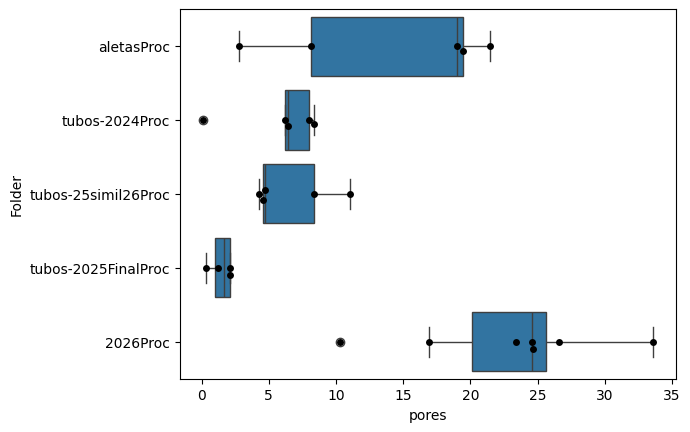

In [28]:
sns.boxplot(data=total, x='pores', y='Folder')
sns.swarmplot(data=total, x='pores', y='Folder', color='black')